**Import Library & Load Data**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load data
train = pd.read_csv('/content/data_training.csv')
test = pd.read_csv('/content/data_testing.csv')

print("=== DATA TRAINING ===")
display(train.head())

print("\n=== DATA TESTING ===")
display(test.head())

print("\nShape Training:", train.shape)
print("Shape Testing:", test.shape)

=== DATA TRAINING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



=== DATA TESTING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516



Shape Training: (857, 13)
Shape Testing: (286, 12)


Data training memiliki 857 observasi dan 13 variabel, sedangkan data testing memiliki 286 observasi dan 12 variabel. Perbedaan jumlah variabel ini disebabkan karena pada data training terdapat variabel quality sebagai target yang akan diprediksi, sementara pada data testing variabel tersebut tidak tersedia.

Berdasarkan tampilan awal data, seluruh variabel berupa fitur numerik yang merepresentasikan karakteristik kimia anggur seperti acidity, pH, alkohol, dan lainnya. Selain itu, terdapat variabel Id yang berfungsi sebagai identitas data dan tidak memiliki pengaruh terhadap proses pemodelan.

Secara keseluruhan, struktur data sudah sesuai untuk analisis klasifikasi, di mana model akan dilatih menggunakan data training dan kemudian digunakan untuk memprediksi nilai quality pada data testing. Perbedaan struktur antara data training dan testing menunjukkan bahwa pendekatan supervised learning digunakan dalam analisis ini.

**Exploratory Data Analysis (EDA)**

**Informasi Dataset**

In [72]:
print("\n=== INFO DATA ===")
train.info()

print("\n=== STATISTIK ===")
display(train.describe())


=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

=== STATISTIK ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Berdasarkan informasi dataset, data training terdiri dari 857 baris dan 13 variabel yang mencakup karakteristik kimia anggur serta variabel target quality.

Sebagian besar variabel memiliki tipe data float64, sedangkan variabel quality dan Id bertipe int64. Selain itu, seluruh variabel memiliki jumlah data non-null sebanyak 857, yang menunjukkan bahwa tidak terdapat missing value pada dataset.

Berdasarkan statistik deskriptif, terlihat bahwa setiap variabel memiliki rentang nilai yang berbeda-beda. Sebagai contoh, variabel alcohol memiliki rata-rata sekitar 10.43, sedangkan variabel density memiliki rata-rata sekitar 0.996. Perbedaan skala antar variabel ini menunjukkan bahwa proses feature scaling diperlukan sebelum pembangunan model machine learning.

Selain itu, variabel target quality memiliki nilai minimum 3 dan maksimum 8 dengan rata-rata sekitar 5.65, yang menunjukkan bahwa sebagian besar kualitas anggur berada pada kategori menengah.

**Distrubusi Variabel Target**

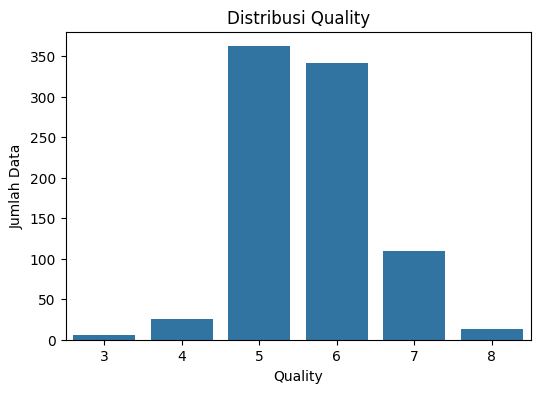

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=train)

plt.title("Distribusi Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")

plt.show()

Berdasarkan grafik distribusi variabel target, terlihat bahwa kualitas anggur paling banyak berada pada kategori 5 dan 6, sedangkan kategori kualitas yang lebih rendah maupun lebih tinggi memiliki jumlah data yang relatif lebih sedikit.

Hal ini menunjukkan bahwa distribusi data target cenderung tidak seimbang (imbalanced), karena beberapa kelas memiliki jumlah observasi yang jauh lebih dominan dibandingkan kelas lainnya. Kondisi ini dapat mempengaruhi performa model, di mana model cenderung lebih mudah memprediksi kelas mayoritas dibandingkan kelas minoritas.

Selain itu, distribusi ini menunjukkan bahwa sebagian besar sampel anggur dalam dataset memiliki kualitas pada tingkat menengah.

**Correlation Matrix**

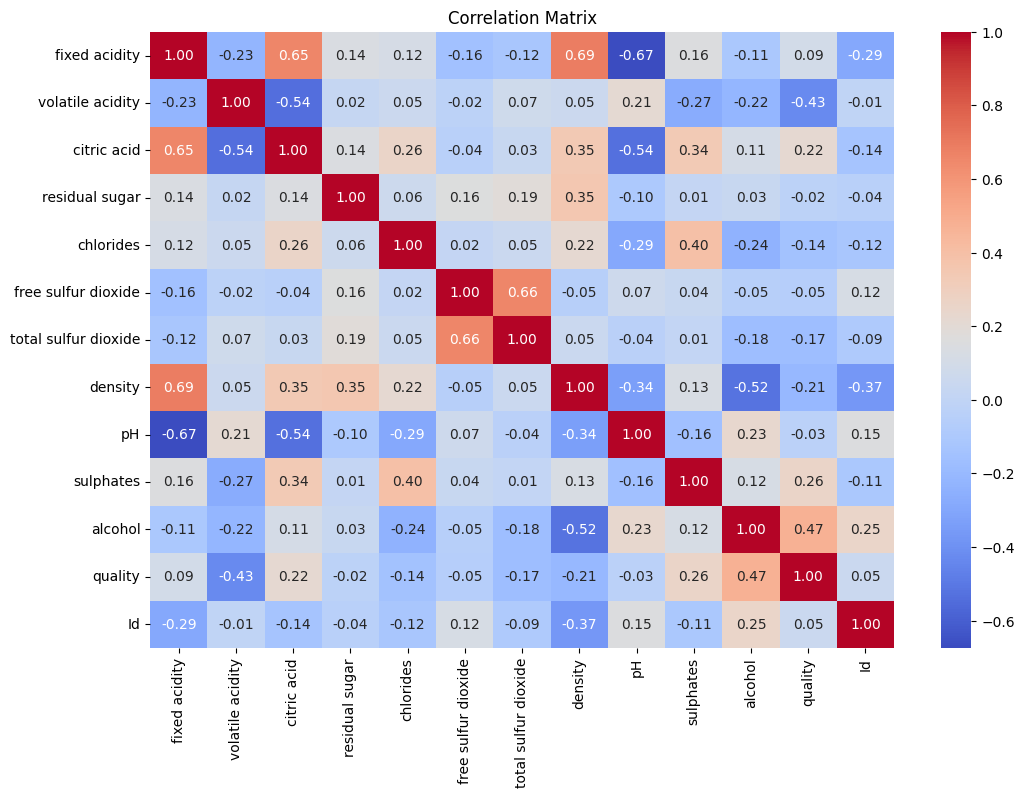

In [74]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Berdasarkan correlation matrix, terlihat bahwa setiap variabel memiliki hubungan yang berbeda terhadap kualitas anggur (`quality`). Nilai korelasi berada pada rentang -1 hingga 1, di mana nilai positif menunjukkan hubungan searah, sedangkan nilai negatif menunjukkan hubungan berlawanan arah. Semakin mendekati angka 1 atau -1, maka hubungan antar variabel semakin kuat.

Hasil visualisasi menunjukkan bahwa variabel `alcohol` memiliki korelasi positif paling tinggi terhadap `quality`, yaitu sebesar 0.47. Hal ini menunjukkan bahwa semakin tinggi kadar alkohol pada anggur, maka kualitas anggur cenderung meningkat. Sebaliknya, variabel `volatile acidity` memiliki korelasi negatif sebesar -0.43 terhadap `quality`, yang menunjukkan bahwa peningkatan tingkat keasaman volatil cenderung menurunkan kualitas anggur.

Selain itu, variabel `sulphates` dan `citric acid` juga memiliki hubungan positif terhadap kualitas anggur, meskipun kekuatan hubungannya tidak terlalu besar. Sementara itu, variabel seperti `density`, `chlorides`, dan `total sulfur dioxide` memiliki hubungan negatif terhadap kualitas anggur, yang menunjukkan bahwa peningkatan nilai variabel tersebut cenderung diikuti penurunan kualitas.

Pada hubungan antar fitur, terlihat beberapa korelasi yang cukup kuat, seperti hubungan positif antara `fixed acidity` dan `density` sebesar 0.69 serta hubungan negatif antara `fixed acidity` dan `pH` sebesar -0.67. Selain itu, `free sulfur dioxide` dan `total sulfur dioxide` juga memiliki hubungan positif yang cukup tinggi sebesar 0.66. Secara keseluruhan, sebagian besar variabel tidak memiliki korelasi yang terlalu kuat satu sama lain sehingga setiap fitur masih memberikan informasi yang berbeda dalam proses prediksi kualitas anggur.


**Data Cleaning**

In [75]:
print("\nMissing Values Training:\n", train.isnull().sum())
print("\nMissing Values Testing:\n", test.isnull().sum())

# Imputasi jika ada missing
train = train.fillna(train.mean())
test = test.fillna(test.mean())


Missing Values Training:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing Values Testing:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Berdasarkan hasil pengecekan missing values, seluruh variabel pada data training maupun data testing memiliki nilai 0, yang berarti tidak terdapat data yang hilang pada dataset.

Hal ini menunjukkan bahwa kualitas data sudah baik dan tidak memerlukan penanganan khusus seperti imputasi atau penghapusan data. Meskipun demikian, langkah imputasi tetap disiapkan sebagai bentuk antisipasi jika terdapat missing value pada kondisi data yang berbeda.

Dengan tidak adanya missing value, proses analisis dapat dilanjutkan ke tahap berikutnya tanpa risiko bias atau kehilangan informasi akibat data yang tidak lengkap. Ketiadaan missing value juga membantu menjaga kestabilan model dalam proses training dan evaluasi.

**Pisahkan Fitur & Target**

In [76]:
X = train.drop(['Id', 'quality'], axis=1)
y = train['quality']

X_test = test.drop(['Id'], axis=1)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Shape X_test:", X_test.shape)

Shape X: (857, 11)
Shape y: (857,)
Shape X_test: (286, 11)


Pada tahap ini dilakukan pemisahan antara fitur (X) dan target (y). Variabel quality digunakan sebagai target yang akan diprediksi, sedangkan variabel lainnya digunakan sebagai fitur input. Variabel Id dihapus karena tidak memiliki pengaruh terhadap kualitas anggur dan hanya berfungsi sebagai identitas data.

Berdasarkan output, diperoleh bahwa X memiliki dimensi (857, 11) yang berarti terdapat 857 data dengan 11 fitur yang digunakan untuk melatih model. Sementara itu, y memiliki dimensi (857,) yang menunjukkan bahwa terdapat 857 label kualitas yang sesuai dengan data fitur.

Pada data testing, diperoleh X_test dengan dimensi (286, 11), yang berarti jumlah fitur yang digunakan sama dengan data training. Hal ini menunjukkan bahwa struktur data testing sudah konsisten dengan data training, sehingga model dapat digunakan untuk melakukan prediksi dengan baik.

Kesesuaian jumlah fitur antara data training dan testing menjadi hal penting agar model dapat bekerja secara optimal tanpa terjadi error atau ketidaksesuaian input.

**Split Data**

In [77]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (685, 11)
X_val: (172, 11)
y_train: (685,)
y_val: (172,)


Pada tahap ini dilakukan pembagian data menjadi data training dan data validation dengan perbandingan 80:20 menggunakan train_test_split.

Berdasarkan hasil output, diperoleh bahwa:

X_train berukuran (685, 11) dan y_train (685,), yang berarti terdapat 685 data yang digunakan untuk melatih model
X_val berukuran (172, 11) dan y_val (172,), yang berarti terdapat 172 data yang digunakan untuk menguji performa model

Jumlah tersebut sudah sesuai dengan proporsi 80% untuk training dan 20% untuk validation dari total 857 data.

Pembagian ini bertujuan untuk memastikan bahwa model tidak hanya belajar dari data training, tetapi juga diuji pada data yang belum pernah dilihat sebelumnya. Dengan demikian, performa model yang dihasilkan lebih mencerminkan kemampuan dalam melakukan prediksi pada data baru (generalisasi).

Selain itu, penggunaan parameter random_state=42 memastikan bahwa pembagian data bersifat konsisten dan dapat direproduksi. Proses ini juga membantu mendeteksi potensi overfitting, yaitu ketika model memiliki performa tinggi pada data training namun kurang baik pada data validation

**Feature Scaling**

In [78]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Sample setelah scaling (X_train):")
print(X_train[:5])

Sample setelah scaling (X_train):
[[-0.80699355 -0.24191336 -0.38083773 -0.62789314 -0.1721627  -0.27598118
  -0.62533275 -0.64952368  0.45473736 -0.10029819 -0.59570451]
 [ 0.72575201  0.19316547  0.02306991 -0.1680498  -0.11324608  0.67091143
   3.09358322  0.60563315 -0.26768432 -0.61174432 -0.98369953]
 [-0.6301383  -0.02437394 -0.68376845 -0.39797147 -0.58457911  0.19746512
  -0.7513977  -0.51065526 -0.66173251  0.1270112  -0.49870576]
 [ 0.489945    0.79139887 -0.78474536  0.21515298  0.10278156 -0.4653597
  -0.05804049  1.171789   -0.00498552 -0.61174432 -0.88670078]
 [-1.04280056 -0.02437394 -1.03718763 -0.39797147 -0.48638473  1.23904699
  -0.05804049 -0.95930707  0.45473736  0.97942141 -0.11071074]]


Pada tahap ini dilakukan feature scaling menggunakan StandardScaler untuk menstandarisasi nilai setiap fitur agar memiliki rata-rata 0 dan standar deviasi 1.

Berdasarkan output yang ditampilkan, terlihat bahwa nilai pada setiap fitur telah berubah menjadi angka desimal dengan rentang yang relatif seragam, termasuk nilai negatif dan positif. Hal ini menunjukkan bahwa data telah berhasil dinormalisasi dari skala awalnya yang berbeda-beda menjadi skala yang sama.

Nilai negatif menunjukkan bahwa data berada di bawah rata-rata, sedangkan nilai positif menunjukkan bahwa data berada di atas rata-rata. Dengan demikian, setiap fitur kini memiliki kontribusi yang lebih seimbang dalam proses pembelajaran model.

Proses scaling dilakukan dengan fit_transform pada data training, kemudian diterapkan pada data validation dan testing menggunakan transform. Hal ini penting untuk menjaga konsistensi dan menghindari kebocoran informasi dari data selain training.

Dengan adanya feature scaling, model seperti Logistic Regression dapat bekerja lebih optimal, sementara untuk Random Forest scaling tidak terlalu berpengaruh, namun tetap membantu menjaga kestabilan proses analisis secara keseluruhan.

**MODEL 1: Logistic Regression**

In [79]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_val)

acc_lr = accuracy_score(y_val, y_pred_lr)

print("=== Logistic Regression ===")
print("Accuracy:", acc_lr)
print(confusion_matrix(y_val, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.5988372093023255
[[ 0  3  0  0  0]
 [ 0 55 12  0  0]
 [ 0 29 42  6  1]
 [ 0  1 14  6  0]
 [ 0  0  0  3  0]]


Model Logistic Regression menghasilkan nilai akurasi sebesar 0.5988 (≈ 59.88%), yang menunjukkan bahwa model mampu memprediksi sekitar 60% data dengan benar pada data validation. Nilai ini tergolong cukup, namun belum optimal.

Berdasarkan confusion matrix, terlihat bahwa model cenderung lebih baik dalam memprediksi kelas yang dominan, khususnya pada kualitas 5 dan 6. Hal ini terlihat dari jumlah prediksi yang cukup besar dan benar pada kelas tersebut, misalnya pada kualitas 5 terdapat 55 prediksi yang tepat.

Namun, model mengalami kesulitan dalam memprediksi kelas lain, terutama kelas dengan jumlah data lebih sedikit seperti kualitas 3 dan 8, yang terlihat dari banyaknya nilai nol atau kesalahan prediksi. Selain itu, terdapat cukup banyak kesalahan prediksi antar kelas yang berdekatan, misalnya antara kualitas 5 dan 6 atau 6 dan 7, yang menunjukkan bahwa model sulit membedakan kelas dengan karakteristik yang mirip.

Hal ini menunjukkan bahwa Logistic Regression memiliki keterbatasan dalam menangkap hubungan kompleks dalam data, terutama karena model ini bersifat linear, sementara hubungan antar fitur dalam dataset kemungkinan bersifat non-linear. Performa model juga dipengaruhi oleh ketidakseimbangan distribusi data, di mana kelas mayoritas lebih mudah diprediksi dibandingkan kelas minoritas.

**MODEL 2: Random Forest**

In [80]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

acc_rf = accuracy_score(y_val, y_pred_rf)

print("=== Random Forest ===")
print("Accuracy:", acc_rf)
print(confusion_matrix(y_val, y_pred_rf))

=== Random Forest ===
Accuracy: 0.5930232558139535
[[ 0  1  2  0  0]
 [ 0 42 25  0  0]
 [ 0 24 51  3  0]
 [ 0  1 11  9  0]
 [ 0  0  0  3  0]]


Model Random Forest menghasilkan akurasi sebesar 0.5930 (≈ 59.30%), yang menunjukkan performa yang hampir sama dengan Logistic Regression dan belum memberikan peningkatan yang signifikan.

Berdasarkan confusion matrix, terlihat bahwa model masih cenderung memprediksi dengan baik pada kelas yang dominan seperti kualitas 5 dan 6, namun mengalami kesulitan dalam membedakan kelas yang berdekatan, misalnya antara kualitas 5, 6, dan 7. Hal ini terlihat dari cukup banyaknya kesalahan prediksi antar kelas tersebut.

Selain itu, kelas dengan jumlah data yang lebih sedikit seperti kualitas 3 dan 8 masih sulit diprediksi dengan baik, yang terlihat dari minimnya prediksi yang benar pada kelas tersebut. Hal ini mengindikasikan bahwa model masih terpengaruh oleh ketidakseimbangan data (class imbalance).

Meskipun Random Forest merupakan model yang mampu menangkap hubungan non-linear, performa yang tidak jauh berbeda dengan Logistic Regression menunjukkan bahwa pola dalam data mungkin tidak terlalu kompleks, atau parameter model yang digunakan belum optimal.

**Perbandingan Model**

In [81]:
print("=== PERBANDINGAN MODEL ===")
print("Logistic Regression:", acc_lr)
print("Random Forest:", acc_rf)

=== PERBANDINGAN MODEL ===
Logistic Regression: 0.5988372093023255
Random Forest: 0.5930232558139535


Berdasarkan hasil perbandingan model, diperoleh bahwa Logistic Regression memiliki akurasi sebesar 0.5988, sedangkan Random Forest memiliki akurasi sebesar 0.5930.

Dari hasil tersebut, terlihat bahwa performa kedua model relatif mirip, namun Logistic Regression sedikit lebih unggul dibandingkan Random Forest. Hal ini menunjukkan bahwa pada dataset ini, model yang lebih sederhana justru mampu memberikan hasil yang lebih baik dibandingkan model yang lebih kompleks.

Hasil ini mengindikasikan bahwa pola dalam data kemungkinan tidak terlalu kompleks atau hubungan antar variabel dapat cukup ditangkap oleh model linear. Selain itu, performa Random Forest yang tidak jauh berbeda juga dapat disebabkan oleh parameter model yang belum dioptimalkan.

**Feature Importance**

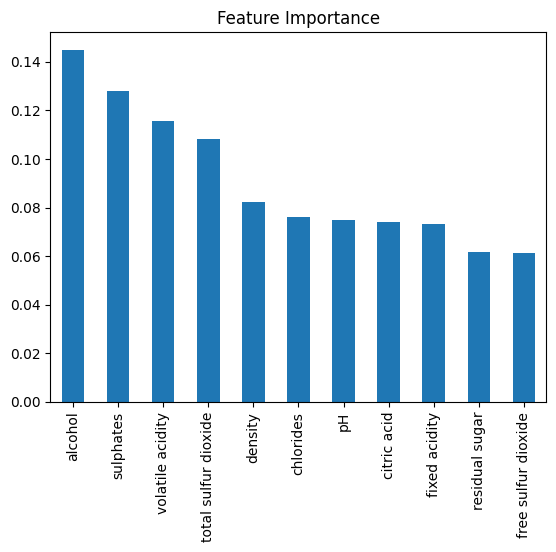


Top Features:
alcohol                 0.144953
sulphates               0.128233
volatile acidity        0.115581
total sulfur dioxide    0.108150
density                 0.082118
chlorides               0.076143
pH                      0.074711
citric acid             0.073969
fixed acidity           0.073055
residual sugar          0.061606
free sulfur dioxide     0.061481
dtype: float64


In [82]:
importance = pd.Series(model_rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

print("\nTop Features:")
print(importance.sort_values(ascending=False))

Berdasarkan hasil feature importance dari model Random Forest, terlihat bahwa setiap variabel memiliki kontribusi yang berbeda dalam memprediksi kualitas anggur.

Variabel dengan pengaruh paling besar adalah alcohol (0.1449), diikuti oleh sulphates (0.1282) dan volatile acidity (0.1156). Hal ini menunjukkan bahwa ketiga variabel tersebut merupakan faktor utama yang berperan dalam menentukan kualitas anggur dalam model yang dibangun.

Selain itu, variabel seperti total sulfur dioxide dan density juga memiliki kontribusi yang cukup signifikan, meskipun tidak sebesar tiga variabel utama. Sementara itu, variabel seperti residual sugar dan free sulfur dioxide memiliki pengaruh yang relatif lebih kecil dibandingkan fitur lainnya.

Dari grafik yang ditampilkan, terlihat bahwa kontribusi fitur tersebar secara bertahap tanpa ada satu fitur yang sangat dominan secara ekstrem. Hal ini menunjukkan bahwa kualitas anggur dipengaruhi oleh kombinasi beberapa variabel, bukan hanya satu faktor utama saja.

**Pilih Model Terbaik**

In [83]:
best_model = model_lr
print("Model terbaik: Logistic Regression")

Model terbaik: Logistic Regression


Berdasarkan hasil evaluasi model, Logistic Regression dipilih sebagai model terbaik karena memiliki nilai akurasi yang sedikit lebih tinggi dibandingkan Random Forest.

Meskipun selisih akurasi antar model relatif kecil, pemilihan ini dilakukan secara objektif berdasarkan hasil performa pada data validation. Hal ini menunjukkan bahwa pada dataset ini, model yang lebih sederhana mampu memberikan hasil yang lebih baik dibandingkan model yang lebih kompleks.

Dengan demikian, Logistic Regression dianggap lebih optimal dalam memprediksi kualitas anggur pada data yang digunakan.

**Prediksi Data Testing**

In [84]:
test_pred = best_model.predict(X_test)

print("=== HASIL PREDIKSI SAMPLE ===")
print(test_pred[:10])

=== HASIL PREDIKSI SAMPLE ===
[5 5 5 5 6 7 5 5 6 5]


Model Logistic Regression yang telah dipilih digunakan untuk melakukan prediksi terhadap data testing. Hasil prediksi berupa nilai kualitas anggur (quality) untuk setiap data yang sebelumnya tidak memiliki label.

Berdasarkan output yang ditampilkan, terlihat bahwa model menghasilkan prediksi dalam bentuk angka diskrit seperti 5 dan 6, yang merupakan kelas kualitas anggur. Hal ini menunjukkan bahwa model mampu mengklasifikasikan data ke dalam kategori kualitas yang telah dipelajari dari data training.

Selain itu, terlihat bahwa sebagian besar hasil prediksi berada pada nilai 5 dan 6, yang sejalan dengan distribusi data sebelumnya di mana kedua kelas tersebut merupakan kelas yang dominan. Hal ini mengindikasikan bahwa model cenderung mengikuti pola distribusi data training dalam melakukan prediksi. Dominasi prediksi pada kelas tertentu juga dapat dipengaruhi oleh ketidakseimbangan data, sehingga model lebih cenderung memprediksi kelas mayoritas dibandingkan kelas minoritas.

**File Submission**

In [85]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'quality': test_pred
})

print("\n=== HASIL AKHIR ===")
display(submission.head())

submission.to_csv('hasilprediksi_3digitNIMterakhir.csv', index=False)


=== HASIL AKHIR ===


,Id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,6


Hasil prediksi dari model Logistic Regression disusun ke dalam format file submission sesuai dengan ketentuan yang diberikan. Dataset hasil akhir terdiri dari dua kolom, yaitu Id sebagai identitas data dan quality sebagai hasil prediksi kualitas anggur.

Berdasarkan output yang ditampilkan, terlihat bahwa setiap nilai Id telah dipasangkan dengan hasil prediksi quality yang dihasilkan oleh model. Format ini sudah sesuai dengan ketentuan, yaitu hanya memuat dua variabel tanpa tambahan kolom lain.

In [86]:
from google.colab import files
files.download('hasilprediksi_3digitNIMterakhir.csv')

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Shape X_test:", X_test.shape)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Shape X: (857, 11)
Shape y: (857,)
Shape X_test: (286, 11)


Berdasarkan hasil output, diperoleh bahwa variabel X memiliki ukuran (857, 11) yang berarti terdapat 857 data dengan 11 fitur yang digunakan sebagai variabel input dalam proses pemodelan.

Sementara itu, variabel y memiliki ukuran (857,) yang menunjukkan bahwa terdapat 857 label quality yang akan diprediksi oleh model. Jumlah data pada X dan y sudah sesuai, sehingga setiap data fitur memiliki pasangan target yang tepat.

Pada data testing, diperoleh ukuran X_test sebesar (286, 11), yang berarti terdapat 286 data testing dengan jumlah fitur yang sama seperti data training, yaitu 11 fitur. Kesamaan jumlah fitur ini penting agar model dapat melakukan prediksi dengan baik pada data baru tanpa terjadi ketidaksesuaian struktur data.

Dengan demikian, dataset telah siap digunakan untuk proses pembagian data, training model, dan prediksi.